In [7]:
# ============================================================
# EfficientNet-B4 (Keras 3 + TF 2.20 Compatible)
# Dermatology-Optimized Training Pipeline with Fine-Tuning
# ============================================================

import os
import keras
import tensorflow as tf
from keras import layers
from keras.utils import image_dataset_from_directory
from keras.applications.efficientnet import EfficientNetB4, preprocess_input

In [8]:
# ----------------------------
# GPU Check
# ----------------------------
if tf.config.list_physical_devices("GPU"):
    print("GPU detected. Using GPU.")
else:
    print("No GPU detected. Training will be slow.")

GPU detected. Using GPU.


In [10]:
TRAIN_DIR  = "dataset/train"
VAL_DIR    = "dataset/valid"
TEST_DIR   = "dataset/test"
OUTPUT_DIR = "./output_efficientnet_b4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:
# ----------------------------
# HYPERPARAMETERS
# ----------------------------
IMAGE_SIZE = (380, 380)   # EfficientNet-B4 default resolution
BATCH_SIZE = 16           # B4 is heavy → 16 recommended
NUM_CLASSES = 7
SEED = 42

EPOCHS = 10
LR = 1e-4
USE_MIXED_PRECISION = True
AUTOTUNE = tf.data.AUTOTUNE

In [12]:
# ----------------------------
# Mixed Precision (AMP)
# ----------------------------
if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")

Mixed precision enabled.


In [13]:
# ============================================================
# DATA LOADING
# ============================================================

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 41995 files belonging to 7 classes.
Found 3499 files belonging to 7 classes.
Found 3499 files belonging to 7 classes.


In [14]:
# ============================================================
# SKIN-DISEASE OPTIMIZED AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),        # small rotation (preserve lesion geometry)
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),        # dermatology-safe contrast change
])


In [15]:
# ============================================================
# PREPROCESSING
# ============================================================

def preprocess_train(images, labels):
    images = preprocess_input(images)  # EfficientNet standardized preprocessing
    images = data_augmentation(images)
    return images, labels

def preprocess_eval(images, labels):
    images = preprocess_input(images)
    return images, labels

train_ds = train_ds.map(preprocess_train, AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_eval, AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval, AUTOTUNE).prefetch(AUTOTUNE)

In [16]:
# ============================================================
# BUILD MODEL — EfficientNet-B4
# ============================================================

base_model = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    pooling="avg"
)

base_model.trainable = False  # freeze for head training

inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs, name="EfficientNet-B4")
model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "EfficientNet-B4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        12,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,686,374 (67.47 MB)

 Trainable params: 12,551 (49.03 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [17]:
# ============================================================
# COMPILE
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=3),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5),
    ]
)

# ============================================================
# CALLBACKS
# ============================================================

callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "best_efficientnet_b4.keras"),
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
]

# ============================================================
# TRAIN PHASE 1 (HEAD ONLY)
# ============================================================

print("\nTraining EfficientNet-B4 (head only)…\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Training EfficientNet-B4 (head only)…

Epoch 1/10


2025-11-15 06:19:38.898941: I external/local_xla/xla/service/service.cc:163] XLA service 0x75076c0046f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-15 06:19:38.898961: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-11-15 06:19:39.731970: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-15 06:19:42.354007: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1763187612.933699  245574 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2625/2625 ━━━━━━━━━━━━━━━━━━━━ 323s 98ms/step - accuracy: 0.4720 - loss: 1.4697 - sparse_top_k_categorical_accuracy: 0.7718 - sparse_top_k_categorical_accuracy_1: 0.9214 - val_accuracy: 0.5787 - val_loss: 1.2261 - val_sparse_top_k_categorical_accuracy: 0.8485 - val_sparse_top_k_categorical_accuracy_1: 0.9557 - learning_rate: 1.0000e-04
Epoch 2/10
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 168s 64ms/step - accuracy: 0.5739 - loss: 1.2143 - sparse_top_k_categorical_accuracy: 0.8473 - sparse_top_k_categorical_accuracy_1: 0.9544 - val_accuracy: 0.6179 - val_loss: 1.1196 - val_sparse_top_k_categorical_accuracy: 0.8682 - val_sparse_top_k_categorical_accuracy_1: 0.9651 - learning_rate: 1.0000e-04
Epoch 3/10
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 168s 64ms/step - accuracy: 0.5991 - loss: 1.1480 - sparse_top_k_categorical_accuracy: 0.8606 - sparse_top_k_categorical_accuracy_1: 0.9608 - val_accuracy: 0.6319 - val_loss: 1.0711 - val_sparse_top_k_categorical_accuracy: 0.8757 - val_sparse_top_k_categorical_accuracy_1:

In [18]:
model.evaluate(test_ds)

219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6616 - loss: 0.9573 - sparse_top_k_categorical_accuracy: 0.8954 - sparse_top_k_categorical_accuracy_1: 0.9728


[0.957256019115448,
 0.6616175770759583,
 0.8953986763954163,
 0.8953986763954163,
 0.9728493690490723]

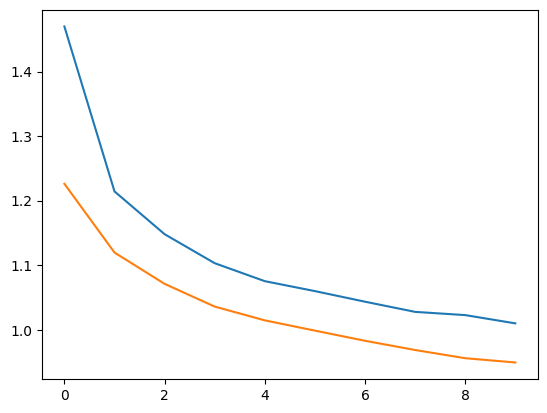

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

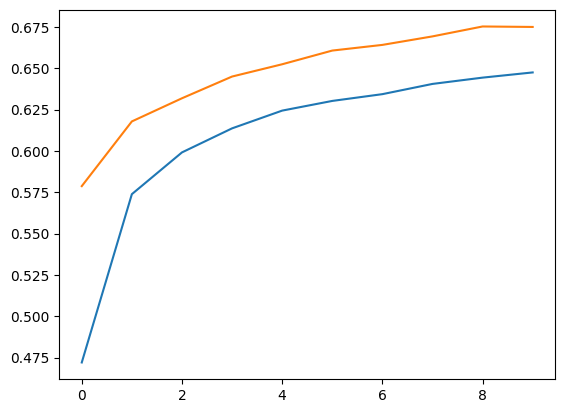

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [25]:
def fine_tune(model, base_model, unfreeze_last=50, ft_epochs=10, ft_lr=1e-5):
    """
    Fine-tune only the last 'unfreeze_last' layers of the backbone.
    Works for EfficientNet, ConvNeXt, MobileNet, DenseNet, etc.
    """
    
    print(f"\nFine-tuning: Unfreezing last {unfreeze_last} layers...\n")

    # -----------------------------------------
    # 1. Freeze ALL layers first
    # -----------------------------------------
    for layer in base_model.layers:
        layer.trainable = False

    # -----------------------------------------
    # 2. Unfreeze the last N layers
    # -----------------------------------------
    for layer in base_model.layers[-unfreeze_last:]:
        layer.trainable = True

    # (Optional) Print info
    trainable_count = sum([layer.trainable for layer in base_model.layers])
    print(f"Trainable layers after unfreezing = {trainable_count}/{len(base_model.layers)}")

    # -----------------------------------------
    # 3. Re-compile with a smaller LR
    # -----------------------------------------
    model.compile(
        optimizer=keras.optimizers.Adam(ft_lr),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.SparseTopKCategoricalAccuracy(k=3),
            keras.metrics.SparseTopKCategoricalAccuracy(k=5),
        ],
    )

    # -----------------------------------------
    # 4. Train again on the fine-tuning schedule
    # -----------------------------------------
    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=ft_epochs,
        callbacks=callbacks,
    )

    return history_ft


In [26]:
# Unfreeze only last 50 layers (good start)
history_ft = fine_tune(
    model,
    base_model,
    unfreeze_last=50,
    ft_epochs=10,
    ft_lr=1e-5
)


Fine-tuning: Unfreezing last 50 layers...

Trainable layers after unfreezing = 50/476
Epoch 1/10
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 344s 103ms/step - accuracy: 0.6221 - loss: 1.0700 - sparse_top_k_categorical_accuracy: 0.8721 - sparse_top_k_categorical_accuracy_1: 0.9625 - val_accuracy: 0.7136 - val_loss: 0.8293 - val_sparse_top_k_categorical_accuracy: 0.9160 - val_sparse_top_k_categorical_accuracy_1: 0.9820 - learning_rate: 1.0000e-05
Epoch 2/10
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 175s 66ms/step - accuracy: 0.6934 - loss: 0.8869 - sparse_top_k_categorical_accuracy: 0.9055 - sparse_top_k_categorical_accuracy_1: 0.9749 - val_accuracy: 0.7476 - val_loss: 0.7243 - val_sparse_top_k_categorical_accuracy: 0.9306 - val_sparse_top_k_categorical_accuracy_1: 0.9849 - learning_rate: 1.0000e-05
Epoch 3/10
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 176s 66ms/step - accuracy: 0.7251 - loss: 0.7883 - sparse_top_k_categorical_accuracy: 0.9220 - sparse_top_k_categorical_accuracy_1: 0.9803 - val_accuracy: 0.7705 - val_loss

In [27]:
model.evaluate(test_ds)

219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.8668 - loss: 0.4078 - sparse_top_k_categorical_accuracy: 0.9663 - sparse_top_k_categorical_accuracy_1: 0.9903


[0.40780189633369446,
 0.8668190836906433,
 0.9662760496139526,
 0.9662760496139526,
 0.9902829527854919]

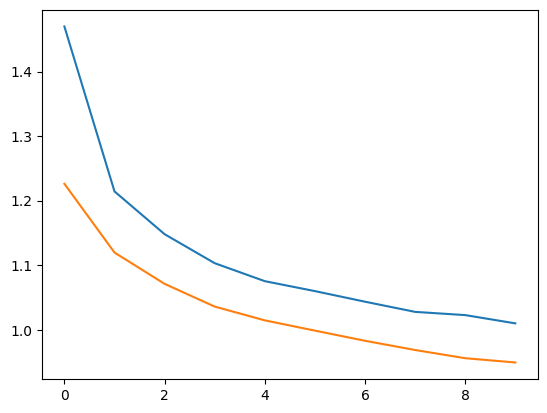

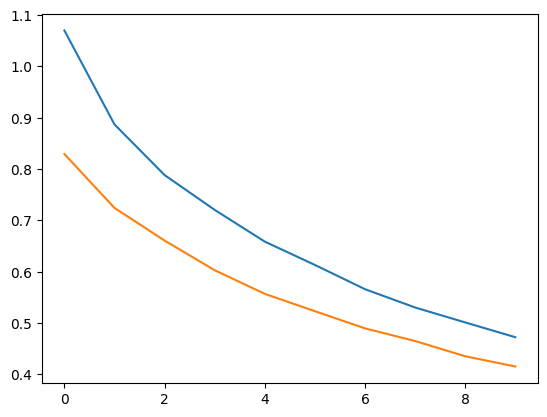

In [37]:
import matplotlib.pyplot as plt

plt.plot(history_ft.history['loss'])
plt.plot(history_ft.history['val_loss'])

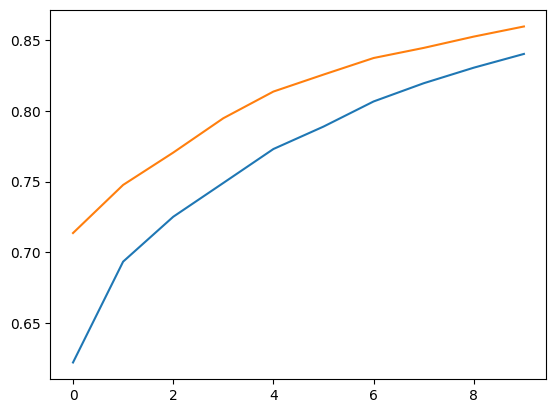

In [38]:
import matplotlib.pyplot as plt

plt.plot(history_ft.history['accuracy'])
plt.plot(history_ft.history['val_accuracy']) 